In [1]:
import sys
print(sys.executable)

/Users/nicole/data-training/.venv/bin/python


In [3]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 
import numpy as np
import json

In [2]:
# read bigquery data into pandas dataframe
import pandas as pd

rfm_df = pd.read_gbq(
    """
    SELECT  *
    FROM `jr-data-training.nicole.rfm`
    --- LIMIT 10
  """,
    project_id="jr-data-training",
)

df = pd.read_gbq(
    """
    SELECT  *
    FROM `jr-data-training.cafe.cafe-sales`
    --- LIMIT 10
  """,
    project_id="jr-data-training",
    location="australia-southeast1",
)

/var/folders/03/kg6152lx62g3z5rhmtm47_c80000gn/T/ipykernel_72498/2834326134.py:4: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  rfm_df = pd.read_gbq(
/var/folders/03/kg6152lx62g3z5rhmtm47_c80000gn/T/ipykernel_72498/2834326134.py:13: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(


In [22]:
rfm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1755 entries, 0 to 1754
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   1755 non-null   Int64  
 1   Recency       1755 non-null   Int64  
 2   Frequency     1755 non-null   Int64  
 3   Monetary      1755 non-null   Int64  
 4   Cluster       1755 non-null   Int64  
 5   R_percentile  1755 non-null   float64
 6   R_score       1755 non-null   Int64  
 7   F_percentile  1755 non-null   float64
 8   F_score       1755 non-null   Int64  
 9   M_percentile  1755 non-null   float64
 10  M_score       1755 non-null   Int64  
 11  RFM_segment   1755 non-null   object 
 12  RFM_score     1755 non-null   Int64  
 13  Score         1755 non-null   object 
dtypes: Int64(9), float64(3), object(2)
memory usage: 207.5+ KB


### Create customer infomation table

In [57]:
customer_df = pd.concat([df['customer_id']], axis=1)
customer_df.drop_duplicates(inplace=True)

In [58]:
# Find the first and lasted purchase date

first_order_dates = df.groupby('customer_id')['date_created'].min()
last_order_dates = df.groupby('customer_id')['date_created'].max()

customer_df = pd.merge(customer_df, first_order_dates, on='customer_id', how='inner')
customer_df = pd.merge(customer_df, last_order_dates, on='customer_id', how='inner')

customer_df.rename(columns={'date_created_x': 'first_order_dates', 'date_created_y': 'last_order_dates'}, inplace=True)

customer_df.reset_index(drop=True, inplace=True)

In [62]:
# calculate the interval period

customer_df['order_interval_period'] = customer_df['last_order_dates'] - customer_df['first_order_dates']
customer_df['order_interval_period'] = customer_df['order_interval_period'].dt.days

In [63]:
# merge RFM value into the table

customer_df = pd.merge(customer_df, rfm_df[['customer_id', 'Recency', 'Frequency', 'Monetary']], on='customer_id', how='inner')

In [69]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1755 entries, 0 to 1754
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            1755 non-null   Int64         
 1   first_order_dates      1755 non-null   datetime64[us]
 2   last_order_dates       1755 non-null   datetime64[us]
 3   order_interval_period  1755 non-null   int64         
 4   Recency                1755 non-null   float64       
 5   Frequency              1755 non-null   float64       
 6   Monetary               1755 non-null   float64       
dtypes: Int64(1), datetime64[us](2), float64(3), int64(1)
memory usage: 97.8 KB


### Customer churn define

In [70]:
# Determine the observation period end date as the last day in the data
observation_period_end = customer_df['last_order_dates'].max()

# Calculate the observation period start date as 30 days before the end date
observation_period_start = observation_period_end - pd.DateOffset(days=30)

# Determine churn based on whether the last order date is before the observation period
customer_df['churn'] = (customer_df['last_order_dates'] < observation_period_start).astype(int)

In [76]:
customer_df.churn.value_counts()

churn
1    1531
0     224
Name: count, dtype: int64

### normalized the data

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and Transform The Data
customer_df[['Recency', 'Frequency', 'Monetary']] = scaler.fit_transform(customer_df[['Recency', 'Frequency', 'Monetary']])

### Model

In [72]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1755 entries, 0 to 1754
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            1755 non-null   Int64         
 1   first_order_dates      1755 non-null   datetime64[us]
 2   last_order_dates       1755 non-null   datetime64[us]
 3   order_interval_period  1755 non-null   int64         
 4   Recency                1755 non-null   float64       
 5   Frequency              1755 non-null   float64       
 6   Monetary               1755 non-null   float64       
 7   churn                  1755 non-null   int64         
dtypes: Int64(1), datetime64[us](2), float64(3), int64(2)
memory usage: 111.5 KB


In [73]:
X = customer_df[['order_interval_period', 'Recency', 'Frequency', 'Monetary']]
y = customer_df[['churn']].values.reshape(-1)

In [75]:
from sklearn.model_selection import train_test_split

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, shuffle=True)

In [78]:
from imblearn.over_sampling import SMOTE

oversample = SMOTE()
X_train_over, y_train_over = oversample.fit_resample(X_train, y_train)
pd.Series(y_train_over).value_counts()

1    1217
0    1217
Name: count, dtype: int64

In [79]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=20).fit(X_train, y_train)
rf_over = RandomForestClassifier(n_estimators=20).fit(X_train_over, y_train_over)

In [80]:
predictions = pd.DataFrame()
predictions['true'] = y_train
predictions['preds'] = rf.predict(X_train)

In [81]:
predictions_test = pd.DataFrame()
predictions_test['true'] = y_test
predictions_test['preds'] = rf.predict(X_test)
predictions_test['preds_over'] = rf_over.predict(X_test)

In [82]:
from sklearn.metrics import classification_report, accuracy_score
train_acc = accuracy_score(predictions.true, predictions.preds)
test_acc = accuracy_score(predictions_test.true, predictions_test.preds)
test_acc_over = accuracy_score(predictions_test.true, predictions_test.preds_over)


print(f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}, Test Acc Oversampled: {test_acc_over:.4f}")

Train Acc: 1.0000, Test Acc: 1.0000, Test Acc Oversampled: 1.0000


In [83]:
print(classification_report(predictions.true, predictions.preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       187
           1       1.00      1.00      1.00      1217

    accuracy                           1.00      1404
   macro avg       1.00      1.00      1.00      1404
weighted avg       1.00      1.00      1.00      1404



In [84]:
print(classification_report(predictions_test.true, predictions_test.preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00       314

    accuracy                           1.00       351
   macro avg       1.00      1.00      1.00       351
weighted avg       1.00      1.00      1.00       351



In [85]:
print(classification_report(predictions_test.true, predictions_test.preds_over))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00       314

    accuracy                           1.00       351
   macro avg       1.00      1.00      1.00       351
weighted avg       1.00      1.00      1.00       351



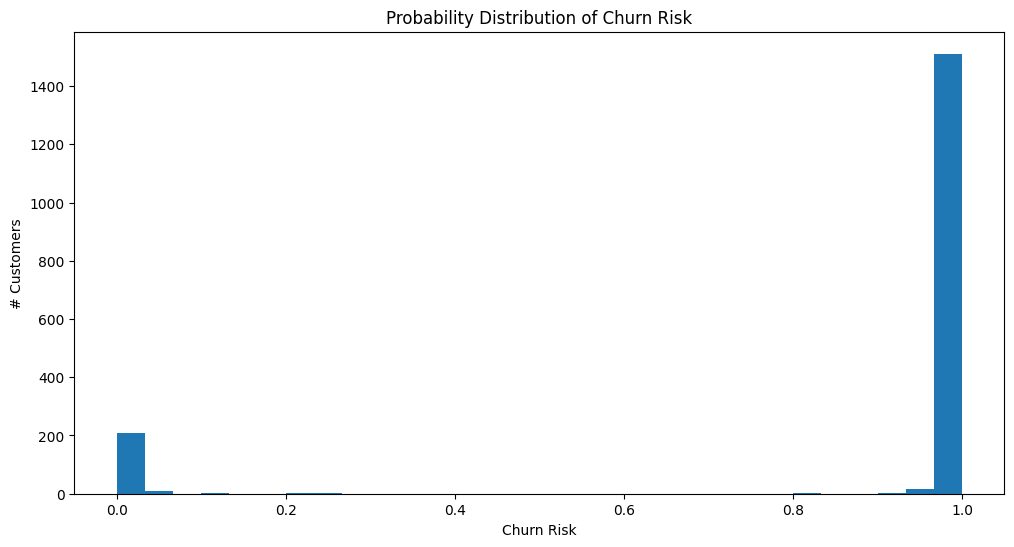

In [92]:
current_rfm = customer_df.copy().set_index('customer_id')
current_rfm.drop(columns=['churn', 'first_order_dates', 'last_order_dates'], inplace=True)
probs = rf_over.predict_proba(current_rfm)[:, 1]

plt.figure(figsize=(12, 6))
# matplotlib histogram
plt.hist(probs, bins = int(180/6))

plt.title('Probability Distribution of Churn Risk')
plt.xlabel('Churn Risk')
plt.ylabel('# Customers')
plt.show()

挠头。。。。。